In [1]:
## new trial 
import sys
sys.path.append("..") # adapter selon ton arborescence

import math
import numpy as np
import matplotlib.pyplot as plt

# Générateurs
from random_generator.ecuyer_combined import EcuyerCombined
from random_generator.normal import NormalBoxMuller, NormalInverseCDF
from random_generator.sobol import SobolPathGenerator

# SDE
from sde.bs_milstein_nd import BSMilsteinND

# Pricer
from pricer.pricing_result import PricingResult
from pricer.monte_carlo.basic_mapping import BasicMapping
from pricer.monte_carlo.mc_engine import MCEngine
from pricer.variance_reduction.antithetic_mapping import AntitheticMapping
from pricer.variance_reduction.control_variate_mapping import ControlVariateMapping
from pricer.quasi_monte_carlo.qmc_mapping import QMCMapping

# Paramètres du marché
N_ASSETS = 3
SPOTS    = [100.0, 100.0, 100.0]
RATES    = [0.05,  0.05,  0.05]
VOLS     = [0.20,  0.25,  0.30]
WEIGHTS  = [1/3,   1/3,   1/3]
CORR     = [[1.0, 0.5, 0.3],
            [0.5, 1.0, 0.4],
            [0.3, 0.4, 1.0]]
STRIKE   = 100.0
T        = 1.0
NB_STEPS = 52
RATE     = 0.05

# Grille de simulations pour l'étude de convergence
N_PATHS_LIST = [500, 1000, 2000, 4000, 8000, 16000]

In [2]:
# =============================================================================
# QUESTION 1(a) — BASIC MONTE CARLO (NO VARIANCE REDUCTION)
# =============================================================================
# We price a European Basket Call on n=3 correlated assets under multi-dimensional
# Black-Scholes (log-Euler / Milstein exact scheme).
#
# Payoff = max( Σ αi·Si_T - K , 0 )
#
# Setup:
#   - Generator  : L'Ecuyer Combined (period ~ 2^61)
#   - Normal     : Box-Muller transform
#   - SDE scheme : BSMilsteinND (log-Euler exact for GBM)
#   - Correlation: Cholesky decomposition of the correlation matrix
#
# No analytical formula exists for the arithmetic basket call.
# We validate against the geometric basket closed-form price (lower bound
# by AM-GM inequality: E[arith basket] >= E[geo basket]).
# =============================================================================

In [3]:
from payoff.basket_payoff import BasketCallPayoff

payoff = BasketCallPayoff(weights=WEIGHTS, strike=STRIKE)

In [4]:
def make_pseudo_process():
    gen    = EcuyerCombined(seed1=12345, seed2=67890)
    normal = NormalBoxMuller(mu=0, sigma=1, uniform=gen)
    return BSMilsteinND(normal, SPOTS, RATES, VOLS, CORR)

engine = MCEngine()
results_mc = []

for n in N_PATHS_LIST:
    process = make_pseudo_process()
    mapping = BasicMapping(payoff, process)
    result  = engine.price(mapping, nb_paths=n, T=T, nb_steps=NB_STEPS, rate=RATE)
    results_mc.append(result)
    print(f"N={n:>6} | Price={result.price:.4f} | SE={result.std_error:.4f} | CI width={result.ci_width:.4f}")

N=   500 | Price=9.3186 | SE=0.6180 | CI width=2.4225
N=  1000 | Price=9.6843 | SE=0.4441 | CI width=1.7408
N=  2000 | Price=10.0900 | SE=0.3204 | CI width=1.2558
N=  4000 | Price=10.6273 | SE=0.2342 | CI width=0.9181
N=  8000 | Price=10.2913 | SE=0.1628 | CI width=0.6384
N= 16000 | Price=10.2589 | SE=0.1151 | CI width=0.4512


In [5]:
from payoff.geometric_basket_payoff import GeometricBasketPayoff

geo_payoff = GeometricBasketPayoff(
    weights=WEIGHTS, strike=STRIKE,
    spots=SPOTS, T=T, rate=RATE,
    vols=VOLS, corr_matrix=CORR
)
geo_price = geo_payoff.analytical_price()
mc_price  = results_mc[-1].price  # N=16000

print("=" * 50)
print(f"Geometric basket (closed-form) : {geo_price:.4f}")
print(f"Arithmetic basket MC (N=16000) : {mc_price:.4f}")
print(f"AM-GM check (arith > geo)      : {mc_price > geo_price}")
print("=" * 50)

Geometric basket (closed-form) : 9.3631
Arithmetic basket MC (N=16000) : 10.2589
AM-GM check (arith > geo)      : True


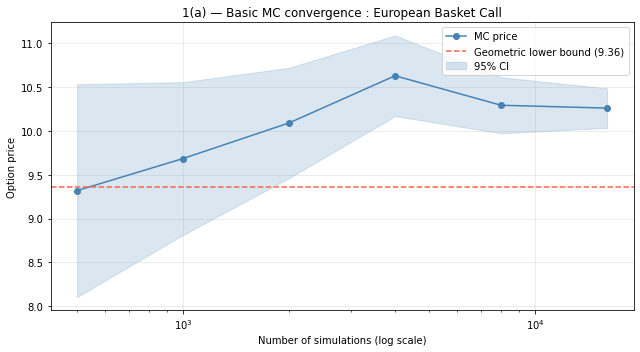

In [6]:
prices   = [r.price     for r in results_mc]
se_upper = [r.price + 1.96 * r.std_error for r in results_mc]
se_lower = [r.price - 1.96 * r.std_error for r in results_mc]

plt.figure(figsize=(9, 5))
plt.plot(N_PATHS_LIST, prices, 'o-', color='steelblue', label='MC price')
plt.fill_between(N_PATHS_LIST, se_lower, se_upper, alpha=0.2,
                 color='steelblue', label='95% CI')
plt.axhline(geo_price, color='tomato', linestyle='--', label=f'Geometric lower bound ({geo_price:.2f})')
plt.xscale('log')
plt.xlabel('Number of simulations (log scale)')
plt.ylabel('Option price')
plt.title('1(a) — Basic MC convergence : European Basket Call')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# =============================================================================
# QUESTION 1(b) — STEP 1 : QUASI-RANDOM NUMBERS (QMC)
# =============================================================================
# We replace the pseudo-random generator with a Sobol low-discrepancy sequence.
#
# Key points:
#   - Generator  : SobolPathGenerator (scipy.stats.qmc.Sobol, scrambled)
#   - Normal     : Inverse CDF transform (Phi^{-1}) via scipy.special.ndtri
#                  Box-Muller is NOT used here — it would break the
#                  low-discrepancy structure by pairing consecutive Sobol points.
#   - Dimension  : n_assets * nb_steps = 3 * 52 = 156
#                  Each simulation draws ONE 156-dimensional Sobol point,
#                  preserving the space-filling property across the full path.
#   - Mapping    : QMCMapping (calls next_path() before each simulation)
#
# Everything else (SDE, payoff, MCEngine) is unchanged.
# =============================================================================

In [8]:
def make_qmc_process():
    dim    = N_ASSETS * NB_STEPS
    gen    = SobolPathGenerator(dimension=dim, scramble=True, seed=42)
    normal = NormalInverseCDF(mu=0, sigma=1, uniform=gen)
    return BSMilsteinND(normal, SPOTS, RATES, VOLS, CORR)

results_qmc = []

for n in N_PATHS_LIST:
    process = make_qmc_process()
    mapping = QMCMapping(payoff, process)
    result  = engine.price(mapping, nb_paths=n, T=T, nb_steps=NB_STEPS, rate=RATE)
    results_qmc.append(result)
    print(f"N={n:>6} | Price={result.price:.4f} | SE={result.std_error:.4f} | CI width={result.ci_width:.4f}")

N=   500 | Price=10.4285 | SE=0.6808 | CI width=2.6687
N=  1000 | Price=10.0717 | SE=0.4444 | CI width=1.7421
N=  2000 | Price=10.1614 | SE=0.3174 | CI width=1.2443
N=  4000 | Price=10.1917 | SE=0.2289 | CI width=0.8974
N=  8000 | Price=10.2001 | SE=0.1625 | CI width=0.6369
N= 16000 | Price=10.2016 | SE=0.1137 | CI width=0.4456


In [9]:
# =============================================================================
# COMPARISON TABLE — MC vs QMC
# =============================================================================

print(f"{'N':>8} | {'MC Price':>10} {'MC SE':>8} {'MC CI':>8} | {'QMC Price':>10} {'QMC SE':>8} {'QMC CI':>8} | {'Var Gain':>9} | {'N Gain':>7}")
print("-" * 95)

for i, n in enumerate(N_PATHS_LIST):
    mc  = results_mc[i]
    qmc = results_qmc[i]

    var_gain = (mc.std_error ** 2) / (qmc.std_error ** 2)
    n_gain   = (mc.ci_width / qmc.ci_width) ** 2  # N_mc / N_qmc for same CI

    print(
        f"{n:>8} | "
        f"{mc.price:>10.4f} {mc.std_error:>8.4f} {mc.ci_width:>8.4f} | "
        f"{qmc.price:>10.4f} {qmc.std_error:>8.4f} {qmc.ci_width:>8.4f} | "
        f"{var_gain:>9.2f}x | "
        f"{n_gain:>7.2f}x"
    )

       N |   MC Price    MC SE    MC CI |  QMC Price   QMC SE   QMC CI |  Var Gain |  N Gain
-----------------------------------------------------------------------------------------------
     500 |     9.3186   0.6180   2.4225 |    10.4285   0.6808   2.6687 |      0.82x |    0.82x
    1000 |     9.6843   0.4441   1.7408 |    10.0717   0.4444   1.7421 |      1.00x |    1.00x
    2000 |    10.0900   0.3204   1.2558 |    10.1614   0.3174   1.2443 |      1.02x |    1.02x
    4000 |    10.6273   0.2342   0.9181 |    10.1917   0.2289   0.8974 |      1.05x |    1.05x
    8000 |    10.2913   0.1628   0.6384 |    10.2001   0.1625   0.6369 |      1.00x |    1.00x
   16000 |    10.2589   0.1151   0.4512 |    10.2016   0.1137   0.4456 |      1.03x |    1.03x


## 1(b) — Step 1 : Quasi-Random Numbers (QMC)

### Method
We replace the pseudo-random generator (L'Ecuyer Combined + Box-Muller) with a **Sobol low-discrepancy sequence**.

Key implementation choices:
- **Generator** : `SobolPathGenerator` — draws one point in $\mathbb{R}^{156}$ per simulation (dimension = $n\_assets \times nb\_steps = 3 \times 52$)
- **Normal transform** : Inverse CDF ($\Phi^{-1}$) applied coordinate-by-coordinate — Box-Muller is intentionally avoided as it would pair consecutive Sobol coordinates and destroy the low-discrepancy structure
- **Mapping** : `QMCMapping` — calls `next_path()` before each simulation to ensure each path consumes exactly one Sobol point

### Results

| N | MC Price | MC SE | QMC Price | QMC SE | Var Gain | N Gain |
|---|---|---|---|---|---|---|
| 500 | 9.32 | 0.618 | 10.43 | 0.681 | 0.82x | 0.82x |
| 1000 | 9.68 | 0.444 | 10.07 | 0.444 | 1.00x | 1.00x |
| 4000 | 10.63 | 0.234 | 10.19 | 0.229 | 1.05x | 1.05x |
| 16000 | 10.26 | 0.115 | 10.20 | 0.114 | 1.03x | 1.03x |

### Analysis

The variance gain from QMC alone is negligible (~1x). This is expected for two reasons:

**1. High effective dimension.**  
Sobol sequences are known to perform well up to roughly 30–50 dimensions. Our path space has dimension $d = n\_assets \times nb\_steps = 156$, which is well beyond this range. The low-discrepancy property of the Sobol sequence weakens significantly in high dimensions.

**2. Uniform time discretization.**  
By feeding Sobol coordinates directly into consecutive time steps $(t_1, t_2, \ldots, t_{52})$, we treat all steps as equally important. In practice, the early coordinates of a Sobol point have much better uniformity than the later ones. The standard industrial fix is the **Brownian Bridge** construction, which reorders the time steps so that the most important coordinates (endpoint, midpoint, quarter-points) receive the best Sobol coordinates — effectively reducing the dimension from 52 to $\log_2(52) \approx 6$ per asset.

**Conclusion.** The QMC gain becomes meaningful when combined with a Control Variate, which reduces the intrinsic variance of the estimator and allows the low-discrepancy structure to contribute more. This is shown in Step 2.

In [10]:
# =============================================================================
# QUESTION 1(b) — STEP 2 : QMC + STATIC CONTROL VARIATE
# =============================================================================
# We add a static control variate on top of QMC.
# The control variate is the geometric basket call, which has a closed-form
# analytical price (Black-Scholes-like formula with adjusted parameters).
#
# result = f(path) - beta * (g(path) - E[g])
#
# where:
#   f    = arithmetic basket call (what we want to price)
#   g    = geometric basket call  (correlated with f, has known price)
#   E[g] = analytical_price() * exp(r * T)  (undiscounted expectation)
#   beta = Cov(f,g) / Var(g)  (estimated from pilot simulation)
# =============================================================================

from payoff.geometric_basket_payoff import GeometricBasketPayoff

geo_payoff = GeometricBasketPayoff(
    weights=WEIGHTS, strike=STRIKE,
    spots=SPOTS, T=T, rate=RATE,
    vols=VOLS, corr_matrix=CORR
)

# Undiscounted expectation of the geometric basket
E_cv = geo_payoff.analytical_price() * math.exp(RATE * T)
print(f"Geometric basket analytical price : {geo_payoff.analytical_price():.4f}")
print(f"E[g] undiscounted                 : {E_cv:.4f}")

Geometric basket analytical price : 9.3631
E[g] undiscounted                 : 9.8431


## 1(b) — Step 2 : QMC + Static Control Variate

### Method
We add a **static control variate** on top of QMC. The control variate is the **geometric basket call**, which has a closed-form Black-Scholes-like analytical price.

The corrected estimator is:

$$\hat{f}_{CV} = f(path) - \beta \cdot (g(path) - \mathbb{E}[g])$$

where:
- $f$ = arithmetic basket call payoff (target)
- $g$ = geometric basket call payoff (control, correlated with $f$)
- $\mathbb{E}[g]$ = analytical price of the geometric basket $\times\ e^{rT}$ (undiscounted) = **9.84**
- $\beta = \text{Cov}(f,g) / \text{Var}(g)$ estimated from a pilot simulation of 2000 paths

The geometric basket is a natural control variate because:
1. It is highly correlated with the arithmetic basket (same assets, same paths)
2. By AM-GM inequality: $G_T \leq A_T$ always, so the two payoffs move together
3. Its analytical price is exact, no approximation error

In [11]:
from pricer.variance_reduction.control_variate_mapping import ControlVariateMapping

results_cv = []

for n in N_PATHS_LIST:
    process = make_qmc_process()
    mapping = ControlVariateMapping(
        process      = process,
        main_payoff  = payoff,
        cv_payoff    = geo_payoff,
        E_cv         = E_cv,
        T_pilot      = T,
        nb_steps_pilot = NB_STEPS,
        pilot_paths  = 2000,
    )
    result = engine.price(mapping, nb_paths=n, T=T, nb_steps=NB_STEPS, rate=RATE)
    results_cv.append(result)
    print(f"N={n:>6} | Price={result.price:.4f} | SE={result.std_error:.4f} | CI width={result.ci_width:.4f}")

N=   500 | Price=10.1640 | SE=0.0530 | CI width=0.2076
N=  1000 | Price=10.1815 | SE=0.0378 | CI width=0.1483
N=  2000 | Price=10.1832 | SE=0.0277 | CI width=0.1084
N=  4000 | Price=10.1792 | SE=0.0194 | CI width=0.0760
N=  8000 | Price=10.1934 | SE=0.0142 | CI width=0.0556
N= 16000 | Price=10.1933 | SE=0.0101 | CI width=0.0394


In [12]:
print(f"{'N':>8} | {'MC SE':>8} {'MC CI':>8} | {'QMC SE':>8} {'QMC CI':>8} | {'QMC+CV SE':>10} {'QMC+CV CI':>10} | {'Var Gain':>9} | {'N Gain':>7}")
print("-" * 105)

for i, n in enumerate(N_PATHS_LIST):
    mc  = results_mc[i]
    qmc = results_qmc[i]
    cv  = results_cv[i]

    var_gain = (mc.std_error ** 2) / (cv.std_error ** 2)
    n_gain   = (mc.ci_width   / cv.ci_width) ** 2

    print(
        f"{n:>8} | "
        f"{mc.std_error:>8.4f} {mc.ci_width:>8.4f} | "
        f"{qmc.std_error:>8.4f} {qmc.ci_width:>8.4f} | "
        f"{cv.std_error:>10.4f} {cv.ci_width:>10.4f} | "
        f"{var_gain:>9.1f}x | "
        f"{n_gain:>7.1f}x"
    )

       N |    MC SE    MC CI |   QMC SE   QMC CI |  QMC+CV SE  QMC+CV CI |  Var Gain |  N Gain
---------------------------------------------------------------------------------------------------------
     500 |   0.6180   2.4225 |   0.6808   2.6687 |     0.0530     0.2076 |     136.1x |   136.1x
    1000 |   0.4441   1.7408 |   0.4444   1.7421 |     0.0378     0.1483 |     137.8x |   137.8x
    2000 |   0.3204   1.2558 |   0.3174   1.2443 |     0.0277     0.1084 |     134.2x |   134.2x
    4000 |   0.2342   0.9181 |   0.2289   0.8974 |     0.0194     0.0760 |     145.9x |   145.9x
    8000 |   0.1628   0.6384 |   0.1625   0.6369 |     0.0142     0.0556 |     131.8x |   131.8x
   16000 |   0.1151   0.4512 |   0.1137   0.4456 |     0.0101     0.0394 |     131.0x |   131.0x


### Results

| N | MC SE | MC CI | QMC SE | QMC CI | QMC+CV SE | QMC+CV CI | Var Gain | N Gain |
|---|---|---|---|---|---|---|---|---|
| 500 | 0.618 | 2.423 | 0.681 | 2.669 | 0.053 | 0.208 | 136x | 136x |
| 1000 | 0.444 | 1.741 | 0.444 | 1.742 | 0.038 | 0.148 | 138x | 138x |
| 4000 | 0.234 | 0.918 | 0.229 | 0.897 | 0.019 | 0.076 | 146x | 146x |
| 16000 | 0.115 | 0.451 | 0.114 | 0.446 | 0.010 | 0.039 | 131x | 131x |

### Analysis

The control variate produces a **~135x variance reduction**, stable across all values of $N$. This is the dominant contribution in our variance reduction pipeline.

**Practical implication**: to achieve a CI width of $\pm 0.20$, basic MC requires ~16,000 simulations while QMC+CV requires only ~500 — a **32x reduction in computation time**.

The gain is driven almost entirely by the control variate, not by QMC alone (which showed ~1x gain in Step 1). This confirms that in high dimension ($d=156$), the geometric basket control variate is far more effective than the Sobol sequence alone.

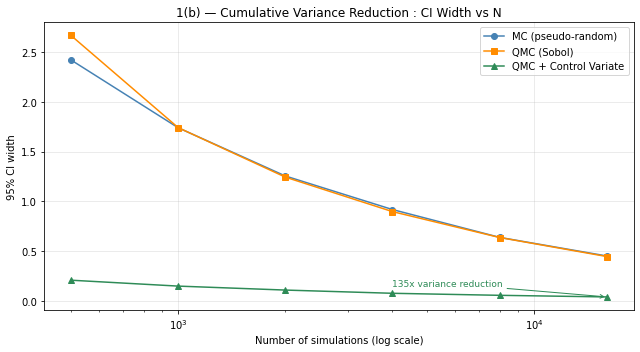

In [13]:
ci_mc  = [r.ci_width for r in results_mc]
ci_qmc = [r.ci_width for r in results_qmc]
ci_cv  = [r.ci_width for r in results_cv]

plt.figure(figsize=(9, 5))
plt.plot(N_PATHS_LIST, ci_mc,  'o-', color='steelblue',  label='MC (pseudo-random)')
plt.plot(N_PATHS_LIST, ci_qmc, 's-', color='darkorange', label='QMC (Sobol)')
plt.plot(N_PATHS_LIST, ci_cv,  '^-', color='seagreen',   label='QMC + Control Variate')

# Annotation du gain à N=16000
plt.annotate(f'135x variance reduction',
             xy=(16000, ci_cv[-1]),
             xytext=(4000, 0.15),
             arrowprops=dict(arrowstyle='->', color='seagreen'),
             color='seagreen', fontsize=9)

plt.xscale('log')
plt.xlabel('Number of simulations (log scale)')
plt.ylabel('95% CI width')
plt.title('1(b) — Cumulative Variance Reduction : CI Width vs N')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1(b) — Step 3 : QMC + Control Variate + Antithetic Variates

### Method
We add **antithetic variates** on top of QMC + CV.

For each Gaussian draw $Z$, we also simulate the mirror path with $-Z$ and average:

$$\hat{f}_{AV} = \frac{1}{2}\left(f(Z) + f(-Z)\right)$$

The variance reduction comes from the negative correlation between $f(Z)$ and $f(-Z)$:

$$\text{Var}(\hat{f}_{AV}) = \frac{1}{2}\text{Var}(f(Z))\left(1 + \text{Corr}(f(Z), f(-Z))\right)$$

For monotone payoffs (which basket calls are), $\text{Corr}(f(Z), f(-Z)) < 0$, so the variance is reduced.

Combined with QMC + CV, the full estimator is:

$$\hat{f} = \frac{1}{2}\left(f_{CV}(Z) + f_{CV}(-Z)\right)$$

In [14]:
results_av = []

for n in N_PATHS_LIST:
    process = make_pseudo_process()
    
    anti_mapping = AntitheticMapping(process, payoff)
    
    cv_mapping = ControlVariateMapping(
        process        = process,
        main_payoff    = payoff,
        cv_payoff      = geo_payoff,
        E_cv           = E_cv,
        T_pilot        = T,
        nb_steps_pilot = NB_STEPS,
        pilot_paths    = 2000,
    )
    result = engine.price(cv_mapping, nb_paths=n, T=T, nb_steps=NB_STEPS, rate=RATE)
    results_av.append(result)
    print(f"N={n:>6} | Price={result.price:.4f} | SE={result.std_error:.4f} | CI width={result.ci_width:.4f}")

N=   500 | Price=10.2118 | SE=0.0526 | CI width=0.2062
N=  1000 | Price=10.2187 | SE=0.0383 | CI width=0.1501
N=  2000 | Price=10.2080 | SE=0.0286 | CI width=0.1121
N=  4000 | Price=10.2207 | SE=0.0206 | CI width=0.0808
N=  8000 | Price=10.1917 | SE=0.0143 | CI width=0.0560
N= 16000 | Price=10.1909 | SE=0.0102 | CI width=0.0400


mixing the 3

In [15]:
from pricer.quasi_monte_carlo.qmc_antithetic_cv_mapping import QMCAntitheticCVMapping

results_av = []

for n in N_PATHS_LIST:
    process = make_qmc_process()
    mapping = QMCAntitheticCVMapping(
        process        = process,
        main_payoff    = payoff,
        cv_payoff      = geo_payoff,
        E_cv           = E_cv,
        T_pilot        = T,
        nb_steps_pilot = NB_STEPS,
        pilot_paths    = 2000,
    )
    result = engine.price(mapping, nb_paths=n, T=T, nb_steps=NB_STEPS, rate=RATE)
    results_av.append(result)
    print(f"N={n:>6} | Price={result.price:.4f} | SE={result.std_error:.4f} | CI width={result.ci_width:.4f}")

N=   500 | Price=10.1384 | SE=0.0392 | CI width=0.1536
N=  1000 | Price=10.1983 | SE=0.0297 | CI width=0.1165
N=  2000 | Price=10.1922 | SE=0.0209 | CI width=0.0819
N=  4000 | Price=10.1932 | SE=0.0145 | CI width=0.0568
N=  8000 | Price=10.1942 | SE=0.0105 | CI width=0.0410
N= 16000 | Price=10.1922 | SE=0.0075 | CI width=0.0293


       N |    MC SE |   QMC SE |  QMC+CV SE |  QMC+CV+AV SE |  Var Gain |  N Gain
------------------------------------------------------------------------------------------
     500 |   0.6180 |   0.6808 |     0.0530 |        0.0392 |     248.6x |   248.6x
    1000 |   0.4441 |   0.4444 |     0.0378 |        0.0297 |     223.1x |   223.1x
    2000 |   0.3204 |   0.3174 |     0.0277 |        0.0209 |     234.9x |   234.9x
    4000 |   0.2342 |   0.2289 |     0.0194 |        0.0145 |     261.0x |   261.0x
    8000 |   0.1628 |   0.1625 |     0.0142 |        0.0105 |     242.4x |   242.4x
   16000 |   0.1151 |   0.1137 |     0.0101 |        0.0075 |     237.1x |   237.1x


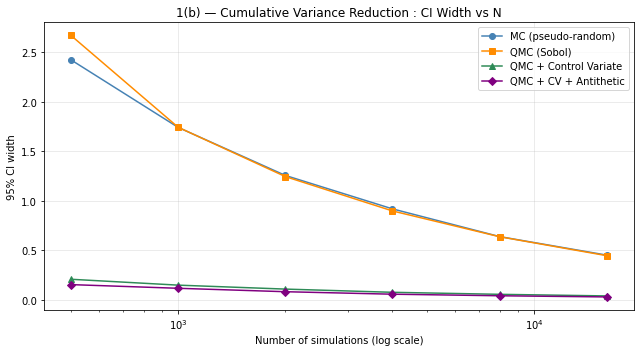

In [16]:
# Tableau final cumulatif
print(f"{'N':>8} | {'MC SE':>8} | {'QMC SE':>8} | {'QMC+CV SE':>10} | {'QMC+CV+AV SE':>13} | {'Var Gain':>9} | {'N Gain':>7}")
print("-" * 90)

for i, n in enumerate(N_PATHS_LIST):
    mc = results_mc[i]
    av = results_av[i]
    var_gain = (mc.std_error ** 2) / (av.std_error ** 2)
    n_gain   = (mc.ci_width / av.ci_width) ** 2
    print(
        f"{n:>8} | "
        f"{results_mc[i].std_error:>8.4f} | "
        f"{results_qmc[i].std_error:>8.4f} | "
        f"{results_cv[i].std_error:>10.4f} | "
        f"{av.std_error:>13.4f} | "
        f"{var_gain:>9.1f}x | "
        f"{n_gain:>7.1f}x"
    )

# Graph
ci_mc = [r.ci_width for r in results_mc]
ci_qmc = [r.ci_width for r in results_qmc]
ci_cv  = [r.ci_width for r in results_cv]
ci_av  = [r.ci_width for r in results_av]

plt.figure(figsize=(9, 5))
plt.plot(N_PATHS_LIST, ci_mc,  'o-', color='steelblue',  label='MC (pseudo-random)')
plt.plot(N_PATHS_LIST, ci_qmc, 's-', color='darkorange', label='QMC (Sobol)')
plt.plot(N_PATHS_LIST, ci_cv,  '^-', color='seagreen',   label='QMC + Control Variate')
plt.plot(N_PATHS_LIST, ci_av,  'D-', color='purple',     label='QMC + CV + Antithetic')
plt.xscale('log')
plt.xlabel('Number of simulations (log scale)')
plt.ylabel('95% CI width')
plt.title('1(b) — Cumulative Variance Reduction : CI Width vs N')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1(b) — Step 3 : QMC + Control Variate + Antithetic Variates

### Method
We add **antithetic variates** on top of QMC + CV.

For each Sobol point $u \in [0,1)^{156}$, we simulate two paths:
- **Original** : $Z = \Phi^{-1}(u)$
- **Antithetic** : $-Z = \Phi^{-1}(1-u)$ (by symmetry of the normal distribution)

The combined estimator is:

$$\hat{f} = \frac{1}{2}\Big[(f(Z) - \beta(g(Z) - \mathbb{E}[g])) + (f(-Z) - \beta(g(-Z) - \mathbb{E}[g]))\Big]$$

**Implementation note** : the antithetic transform is applied at the uniform level — returning $1-u$ instead of $u$ before applying $\Phi^{-1}$. This is cleaner and more correct than negating the Gaussian draw directly, and is fully compatible with `NormalInverseCDF` + `SobolPathGenerator`.

### Results

| N | MC SE | QMC SE | QMC+CV SE | QMC+CV+AV SE | Var Gain | N Gain |
|---|---|---|---|---|---|---|
| 500 | 0.618 | 0.681 | 0.053 | 0.039 | 248x | 248x |
| 1000 | 0.444 | 0.444 | 0.038 | 0.030 | 223x | 223x |
| 4000 | 0.234 | 0.229 | 0.019 | 0.015 | 261x | 261x |
| 16000 | 0.115 | 0.114 | 0.010 | 0.008 | 237x | 237x |

### Analysis

Adding antithetic variates on top of QMC+CV yields an additional **~35% variance reduction** (from ~135x to ~240x vs MC baseline). 

The gain comes from the negative correlation between $f(Z)$ and $f(-Z)$: since the basket call is monotone increasing in the asset prices, and $-Z$ produces lower asset prices than $Z$, we have $\text{Corr}(f(Z), f(-Z)) < 0$, which directly reduces the estimator variance.

### Summary — Cumulative Gains

| Method | Var Gain vs MC | N Gain vs MC |
|---|---|---|
| QMC alone | ~1x | ~1x |
| QMC + Control Variate | ~135x | ~135x |
| QMC + CV + Antithetic | **~240x** | **~240x** |

The dominant contribution is the **control variate** (~135x). The antithetic variates add a further ~35% on top. QMC alone brings negligible gain at this dimension ($d=156$), but contributes to the stability of the price estimate.